In [1]:
import scanpy as sc
#import session_info
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#import seaborn as sns
import math
#from plotnine import *
#import scvi
import os
#import celltypist
#import scanpy
# verbosity: errors (0), warnings (1), info (2), hints (3)
%matplotlib inline
sc.settings.verbosity = 0




In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline

sc.settings.figdir = "supp"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(14,14))


# scRNA

In [3]:
#adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.v8_nohealthy')
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.nohealthy'
adata=sc.read_h5ad(PATH)
adata.obs["Site_status"].value_counts()


Site_status
Non-lesional                         1509239
Lesional                              568318
3D_Week12                             180311
3D_Lesional_baseline                  153479
Healthy                               143446
Week 12                               139631
PostRx                                 96485
Psoriasis_replicate_non-lesional       76048
Week 8 Psoriasis                       72094
Psoriasis_replicate_Lesional           60647
Psoriasis_replicate_PostRx             49385
Day 14_HF                              30438
PostRx-Lesional Dupilumab (16 wk)       6694
PostRx-Lesional Dupilumab (1 yr)        4226
Name: count, dtype: int64

In [4]:
adata = adata[(adata.obs["Patient_status"]=="AD")|
              (adata.obs["Patient_status"]=="3d_Lesional_baseline")|
                (adata.obs["Patient_status"]=="3d_Week12")
                 ].copy()


In [5]:
KEEP = ["PostRx-Lesional Dupilumab (1 yr)",
        'PostRx-Lesional Dupilumab (16 wk)',
        "Week 12","3D_Week12", "3D_Lesional_baseline",
        "Lesional"]
        
adata_i=adata[adata.obs["Site_status"].isin(KEEP)]
adata_i=adata_i[adata_i.obs["lvl5_annotation"]=="TRM_IL13+"].copy()
adata_i.obs["Patient_status"].value_counts()

Patient_status
AD                      13909
3d_Week12                5502
3d_Lesional_baseline     3125
Name: count, dtype: int64

In [6]:
adata.obs.Site_status.value_counts()

Site_status
Non-lesional                         409004
Lesional                             361514
3D_Week12                            180311
3D_Lesional_baseline                 153479
Week 12                              139631
Day 14_HF                             30438
PostRx-Lesional Dupilumab (16 wk)      6694
PostRx-Lesional Dupilumab (1 yr)       4226
Name: count, dtype: int64

In [7]:
adata2 = adata[(adata.obs["Patient_status"]=="AD")].copy()


In [8]:
adata2 = adata2[adata2.obs["Site_status"]=="Lesional"].copy()


In [9]:
# KEEP = ["PostRx-Lesional Dupilumab (1 yr)",
#         'PostRx-Lesional Dupilumab (16 wk)',
#         "Week 12","3D_Week12", "3D_Lesional_baseline",
#         "Lesional"]
        
# adata_i=adata[adata.obs["Site_status"].isin(KEEP)]
# adata_i=adata_i[adata_i.obs["lvl5_annotation"]=="TRM_IL13+"].copy()
# adata_i.obs["Patient_status"].value_counts()

In [10]:

adata_5k=adata2[adata2.obs["tech"]=="xenium"].copy()
adata_scrna=adata2[adata2.obs["tech"]!="xenium"].copy()

#adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna')
import gc
gc.collect()

13390

In [11]:
# adata[adata.obs["Site_status"]=="Lesional"]

In [12]:
# adata_5k.obs.Site_status.value_counts()

In [13]:
def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST






In [14]:
sc.pp.normalize_total(adata_scrna, target_sum=1e4)
sc.pp.log1p(adata_scrna)



In [15]:
sc.pp.normalize_total(adata_5k, target_sum=1e4)
sc.pp.log1p(adata_5k)


In [16]:
# CATEGORY="lvl5_annotation"

# try:
#     adata.obs["trm"] = adata.obs[CATEGORY].astype(str) + "__" +  adata.obs["Site_status"].astype(str)
#     #CATEGORY="lvl3_annotation_patient_status"
#     adata.obs["trm"].value_counts()
# except:
#     1

In [17]:
import gc
gc.collect()

0

In [18]:
# KEEP
adata_scrna.obs.Site_status.value_counts()

Site_status
Lesional    191691
Name: count, dtype: int64

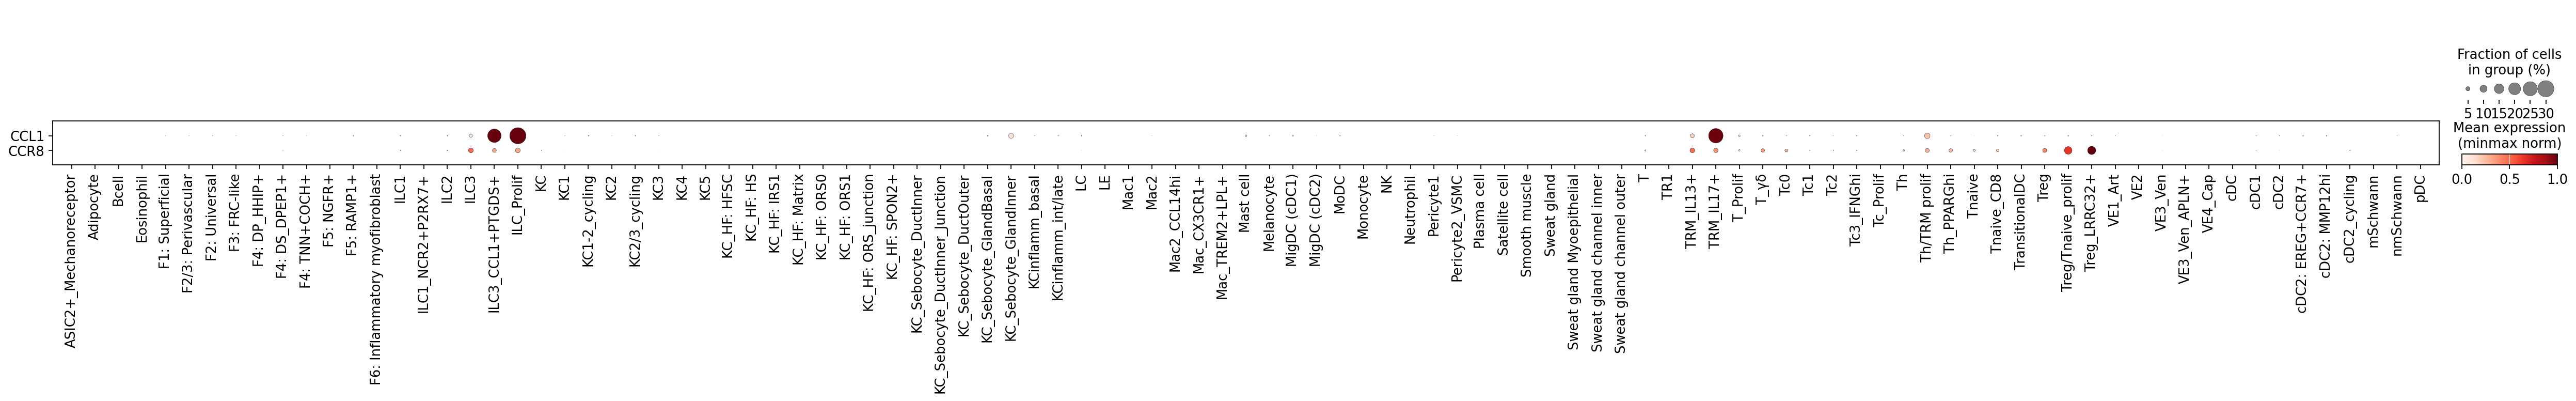

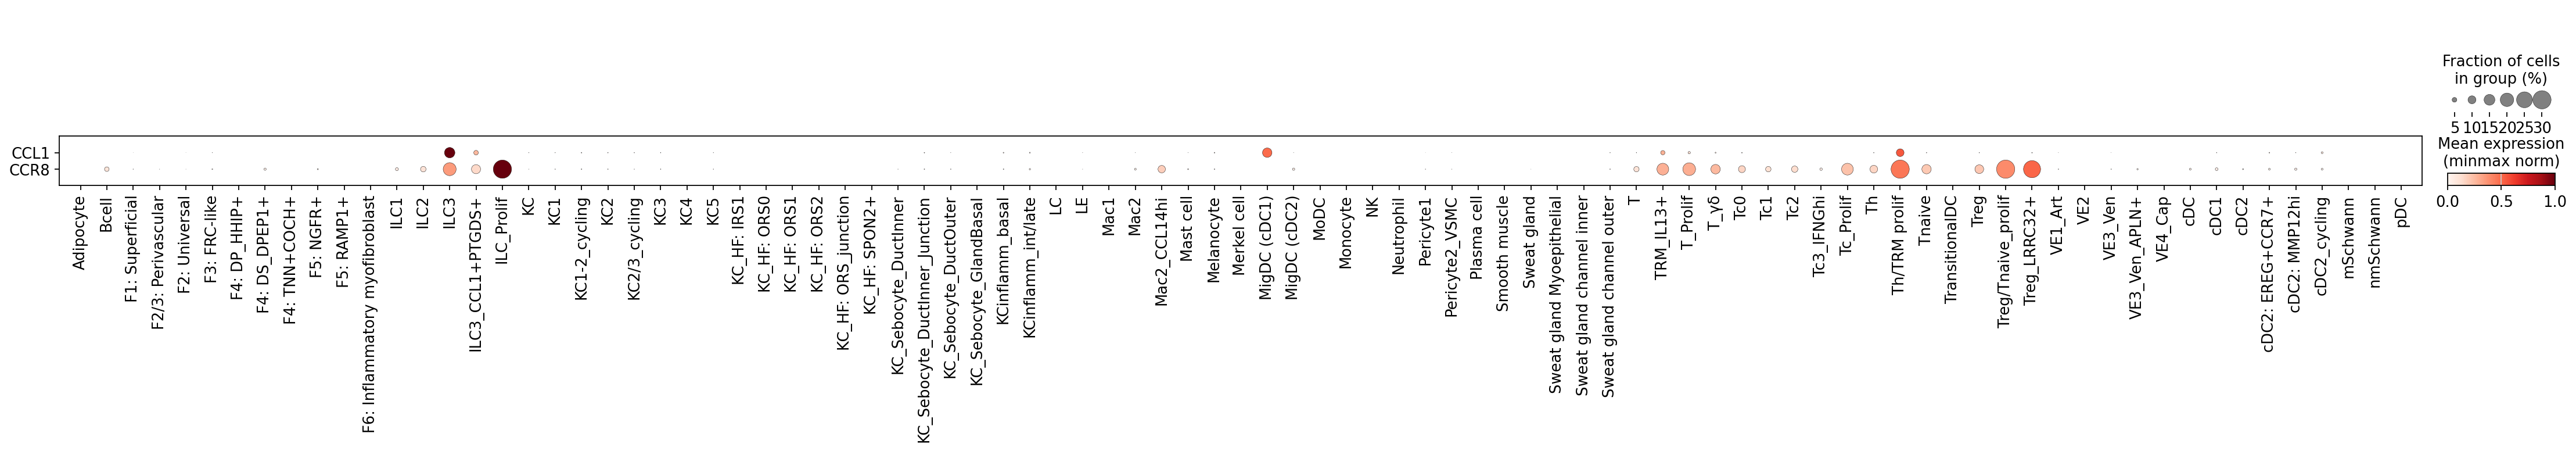

In [19]:
sc.pl.dotplot(adata_scrna[adata_scrna.obs["Site_status"]=="Lesional"], 
              remove_markers(["CCL1", "CCR8"]),
              groupby="lvl5_annotation",
              dendrogram=False, 
                standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
              swap_axes=True,
                dot_max=.3,
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             save="supp1d_ccl1expression_scrna_ALLCELLTYPES.pdf"
             )

sc.pl.dotplot(adata_5k[adata_5k.obs["Site_status"]=="Lesional"], 
              remove_markers(["CCL1", "CCR8"]),
              groupby="lvl5_annotation",
              dendrogram=False, 
                standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(minmax norm)",
                            swap_axes=True,
save='supp1d_ccl1expression_xenium_ALLCELLTYPES.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 

In [20]:
99

99

In [21]:
9

9

In [22]:
KEEP = adata_5k.obs['lvl5_annotation'].unique().tolist()
KEEP=[x for x in KEEP if x not in ['Merkel cell', 'KC_HF: ORS2', 'Neutrophil']]
KEEP2 = adata_scrna.obs['lvl5_annotation'].unique().tolist()
adata_5k=adata_5k[adata_5k.obs['lvl5_annotation'].isin(KEEP2)].copy()

adata_scrna=adata_scrna[adata_scrna.obs['lvl5_annotation'].isin(KEEP)].copy()
adata_5k=adata_5k[adata_5k.obs['lvl5_annotation'].isin(KEEP2)].copy()



In [23]:
[x for x in adata_5k.obs['lvl5_annotation'].unique().tolist() if x not in KEEP]

['Neutrophil']

In [24]:
[x for x in adata_scrna.obs['lvl5_annotation'].unique().tolist() if x not in KEEP]

[]

In [25]:
[x for x in adata_5k.obs['lvl5_annotation'].unique().tolist() if x not in adata_scrna.obs['lvl5_annotation'].unique().tolist()]

['Neutrophil']

In [26]:
adata_scrna.obs["Patient_status"].value_counts()

Patient_status
AD    189508
Name: count, dtype: int64

In [27]:
adata_scrna.obs["Site_status"].value_counts()

Site_status
Lesional    189508
Name: count, dtype: int64

In [28]:
adata_scrna.obs["lvl5_annotation"].nunique()

86

In [29]:
KEEP2 = adata_scrna.obs['lvl5_annotation'].unique().tolist()
adata_5k=adata_5k[adata_5k.obs['lvl5_annotation'].isin(KEEP2)].copy()

adata_5k.obs["lvl5_annotation"].nunique()

86

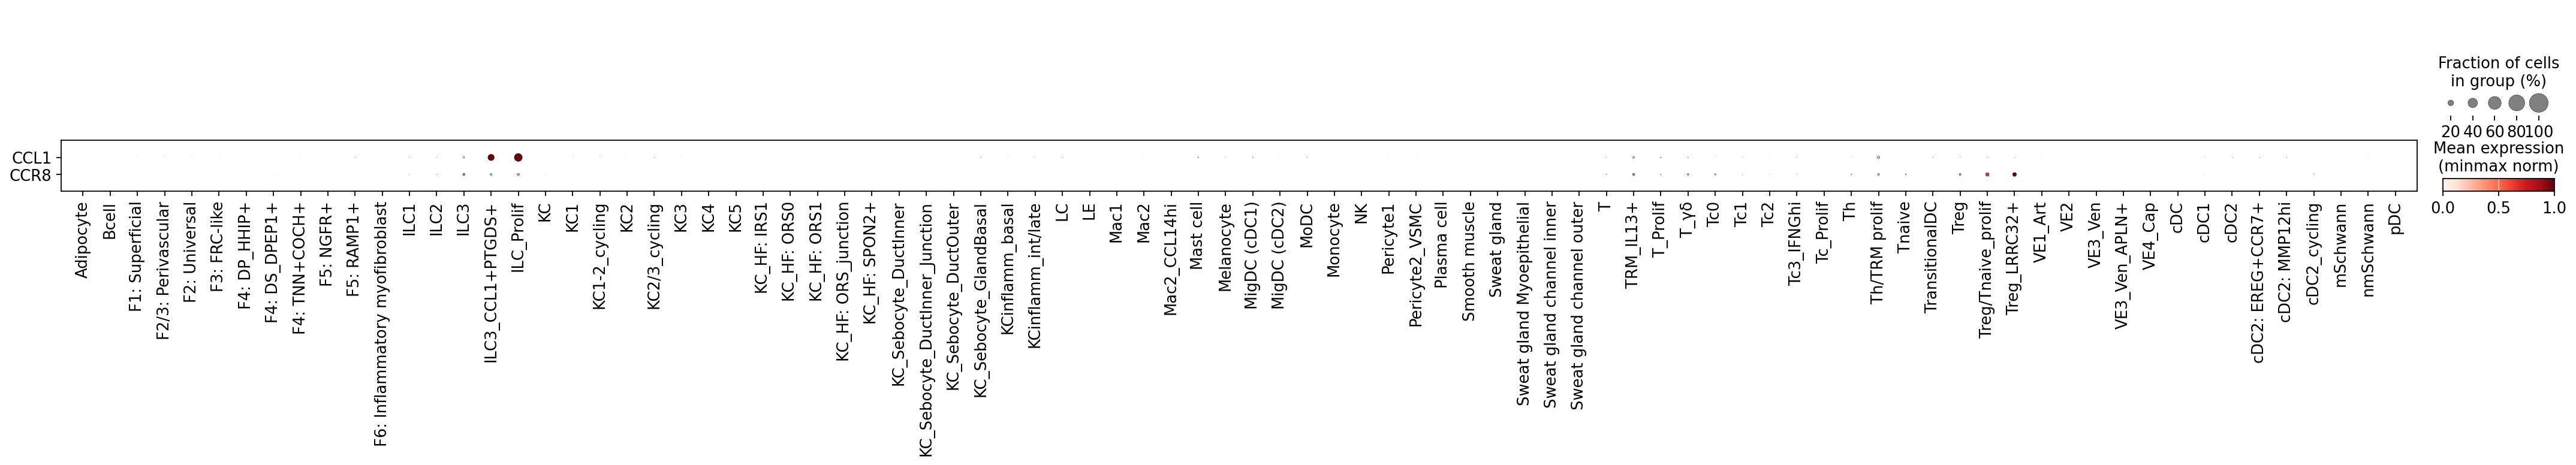

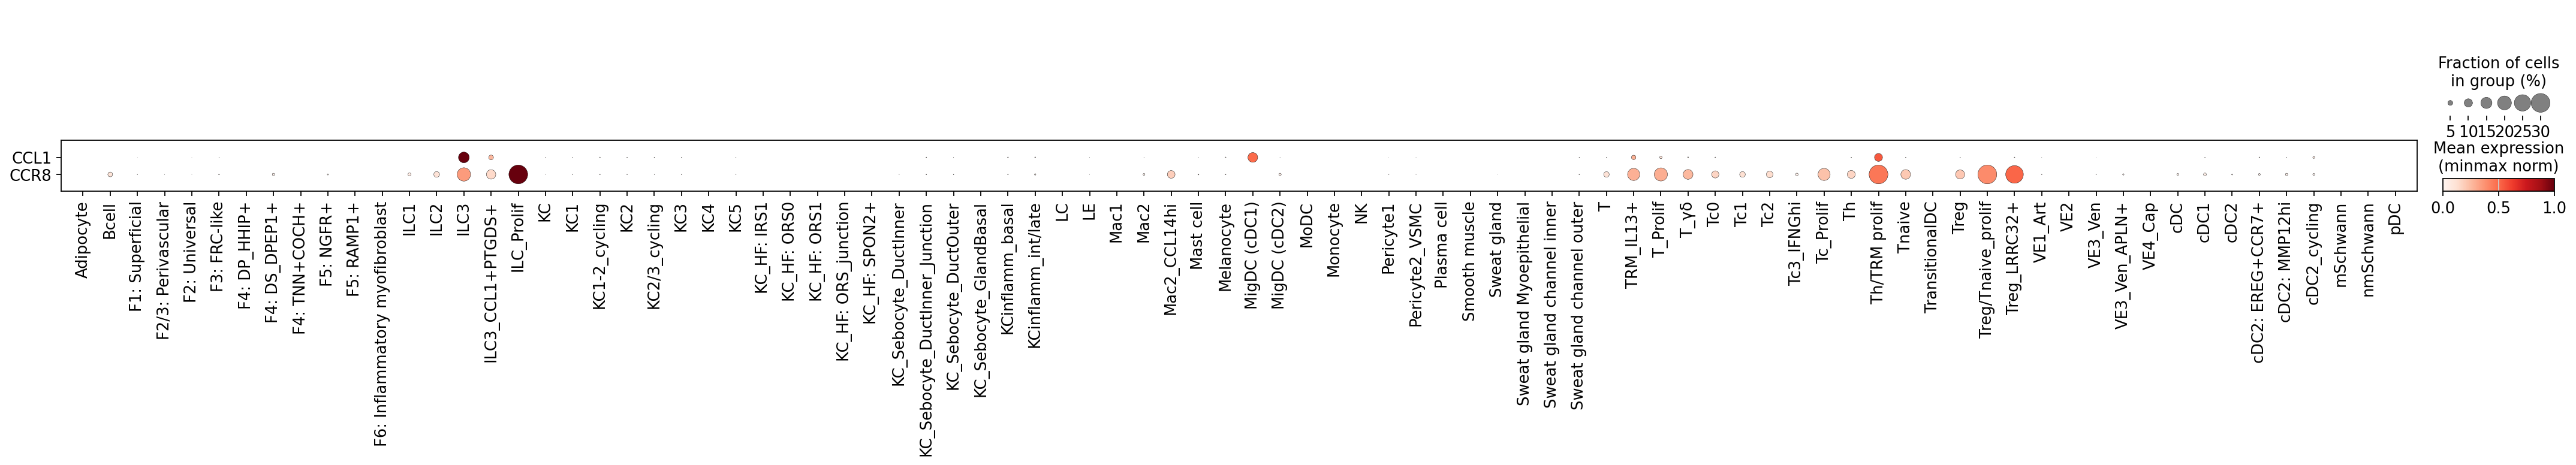

In [39]:
sc.pl.dotplot(adata_scrna[adata_scrna.obs["Site_status"]=="Lesional"], 
              remove_markers(["CCL1", "CCR8"]),
              groupby="lvl5_annotation",
              dendrogram=False, 
                standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
              swap_axes=True,
                dot_max=1,
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             save="supp1d_ccl1expression_scrna.pdf"
             )

sc.pl.dotplot(adata_5k[adata_5k.obs["Site_status"]=="Lesional"], 
              remove_markers(["CCL1", "CCR8"]),
              groupby="lvl5_annotation",
              dendrogram=False, 
                standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(minmax norm)",
                            swap_axes=True,
save='supp1d_ccl1expression_xenium.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 

In [31]:
adata_5k_all=adata[adata.obs["tech"]=="xenium"].copy()

sc.pp.normalize_total(adata_5k_all, target_sum=1e4)
sc.pp.log1p(adata_5k_all)
adata_5k_all.obs.Site_status.value_counts()

Site_status
Non-lesional            287784
3D_Week12               180311
Lesional                169823
3D_Lesional_baseline    153479
Week 12                 139631
Day 14_HF                30438
Name: count, dtype: int64

In [32]:
adata_5k_all=adata_5k_all[adata_5k_all.obs['lvl5_annotation'].isin(KEEP2)].copy()

In [33]:
adata_5k_all[adata_5k_all.obs["Site_status"]=="Week 12"].obs.lvl5_annotation.nunique()

86

In [34]:
# KEEP3 = adata_5k_all[adata_5k_all.obs["Site_status"]=="Week 12"].obs.lvl5_annotation.unique()
# [x for x in KEEP if x not in KEEP3]

In [35]:
adata_5k_all=adata_5k_all[adata_5k_all.obs['lvl5_annotation'].isin(KEEP2)].copy()
adata_5k_all[adata_5k_all.obs["Site_status"]=="Week 12"].obs.lvl5_annotation.nunique()


86

In [36]:
# adata_5k_all[adata_5k_all.obs["Site_status"]=="Week 12"].obs.lvl5_annotation.nunique()


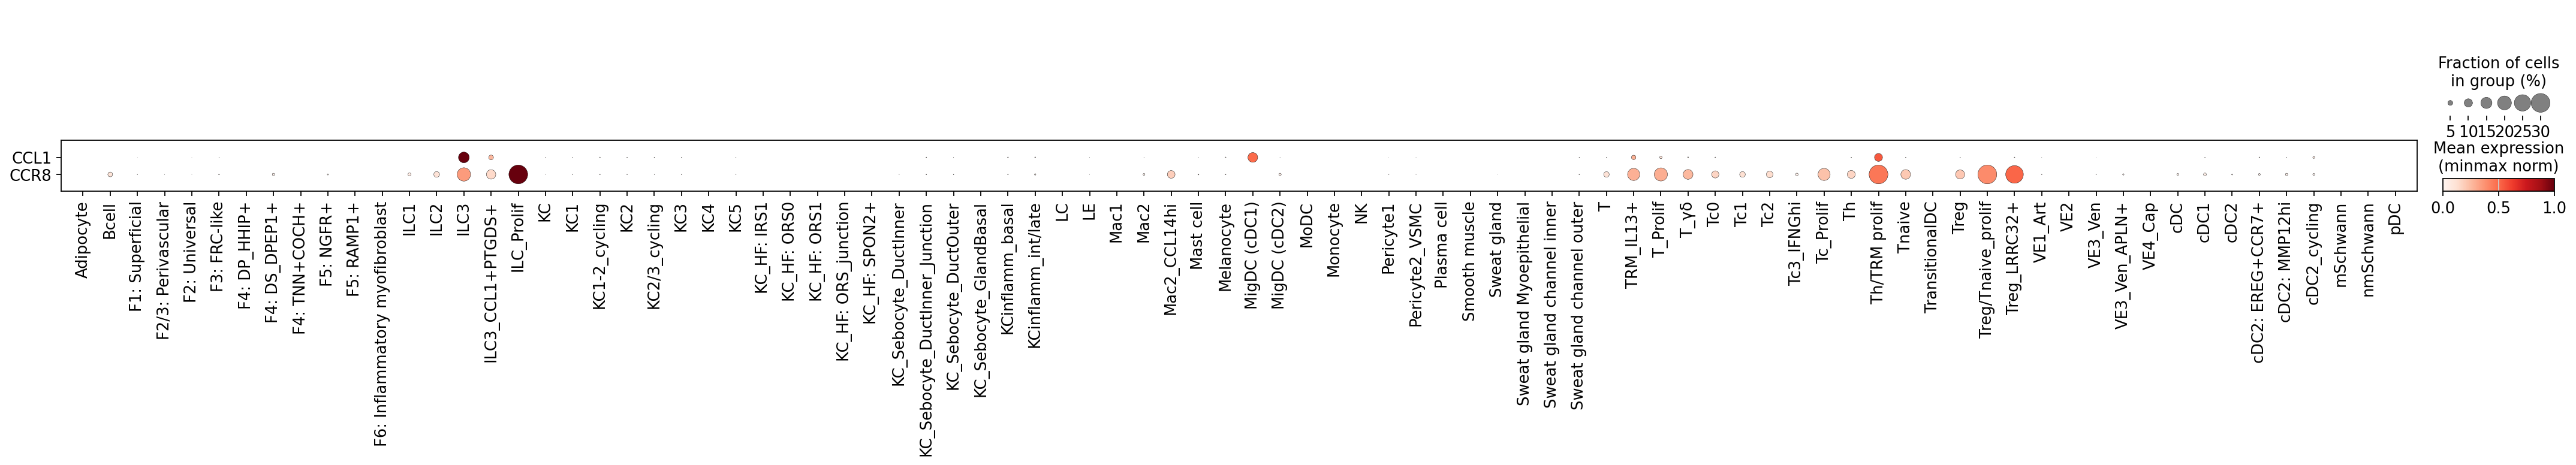

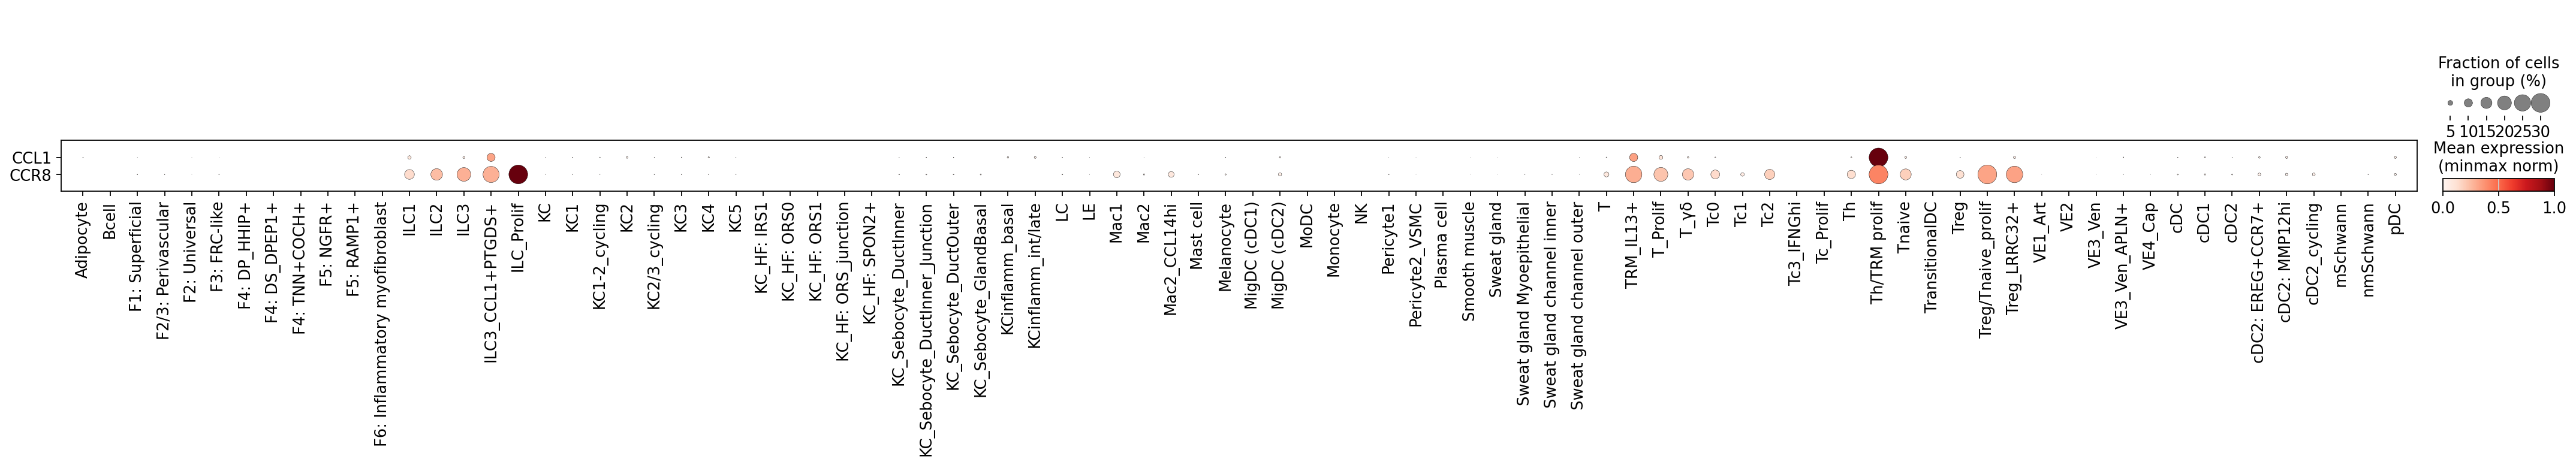

In [37]:
sc.pl.dotplot(adata_5k_all[adata_5k_all.obs["Site_status"]=="Lesional"], 
              remove_markers(["CCL1", "CCR8"]),
              groupby="lvl5_annotation",
              dendrogram=False, 
                standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
              swap_axes=True,
                dot_max=.3,
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             save="supp1d_ccl1expression_xenium_lesional.pdf"
             )

sc.pl.dotplot(adata_5k_all[adata_5k_all.obs["Site_status"]=="Week 12"], 
              remove_markers(["CCL1", "CCR8"]),
              groupby="lvl5_annotation",
              dendrogram=False, 
                standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(minmax norm)",
                            swap_axes=True,
save='supp1d_ccl1expression_xenium_week 12.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 

In [38]:
s

NameError: name 's' is not defined

In [ ]:
sc.pl.dotplot(adata_5k[adata_5k.obs["Site_status"]=="3D_Lesional_baseline"], 
              remove_markers(["CCL1", "CCR8"]),
              groupby="lvl5_annotation",
              dendrogram=False, 
                standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(minmax norm)",
                            swap_axes=True,
#save='supp1d_ccl1expression_xenium.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 

In [ ]:
adata_i.obs.tech.value_counts()

In [ ]:
1

In [ ]:
sc.pp.normalize_total(adata_i, target_sum=1e4)
sc.pp.log1p(adata_i)



In [ ]:






sc.pl.dotplot(adata_i[adata_i.obs["tech"]!="xenium"], 
              remove_markers(["CCL1", "CCR8", "IL13"]),
              groupby="Site_status",
              dendrogram=False, 
                #standard_scale="var",
              colorbar_title="Mean expression\n(minmax norm)",
              swap_axes=True,
                dot_max=.3,
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
            # save="supp1d_ccl1expression_scrna.pdf"
             )

sc.pl.dotplot(adata_i[adata_i.obs["tech"]=="xenium"], 
              ["CCL1", "CCR8", "IL13"],
              groupby="Site_status",
              dendrogram=False, 
               # standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(minmax norm)",
                            swap_axes=True,
#save='supp1d_ccl1expression_xenium.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 

In [ ]:
ALL =   {'Tissue-residency\n markers': ['CD8A', 'ITGAE', 'CD109', 'ZNF683', 'ENTPD1',
                                
                                     'CTSH',
  'VDR',
                                   ],

 'Th2': ['IL13', "CCL1", 'NBAS',# 'CCL17',
         'AREG', 'IL9R',# 'PDLIM4', 
         #'CCR8',
        # 'ZBTB16', 'KLRC4', 'ADGRG1',
         'RGS9',
        "SATB1", "PRDX2", "IL5",
         'IL22', 
        ]}

def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata.var_names]
    return LIST

In [ ]:
# sc.pl.dotplot(adata, 
#               remove_markers(["IL4", "IL13"]),
#               groupby="lvl5_annotation",
#               dendrogram=False, 
#                 standard_scale="var",
#               dot_max=.7,
#               colorbar_title="Mean expression\n(minmax norm)",
#               swap_axes=True,
#              #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
#             # save="supp1d_ccl1expression_scrna.pdf"
#              )

# sc.pl.dotplot(adata_5k, 
#               remove_markers(["IL4", "IL13"]),
#               groupby="lvl5_annotation",
#               dendrogram=False, 
#                 standard_scale="var",
#               dot_max=.3,
#               colorbar_title="Mean expression\n(minmax norm)",
#                             swap_axes=True,
# #save='supp1d_ccl1expression_xenium.pdf'
#              #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
#              # save="supp1d_tdotplot.pdf"
#              )

sc.pl.dotplot(adata_i[adata_i.obs["tech"]!="xenium"], 
              remove_markers(ALL),
              groupby="Site_status",
              dendrogram=False, 
                #standard_scale="var",
              colorbar_title="Mean expression\n(log1p norm)",
            #  swap_axes=True,
                dot_max=.3,
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
            # save="supp1d_ccl1expression_scrna.pdf"
             )
sc.pl.dotplot(adata_i[adata_i.obs["tech"]=="xenium"], 
              remove_markers(ALL),
              groupby="Site_status",
              dendrogram=False, 
               # standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(log1p norm)",
                 #           swap_axes=True,
#save='supp1d_ccl1expression_xenium.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 
adata_xenium_i = adata_i[adata_i.obs["tech"]=="xenium"]
sc.pl.dotplot(adata_xenium_i[adata_xenium_i.obs["niche19"].str.startswith("Epi")],
              remove_markers(ALL),
              groupby="Site_status",
              dendrogram=False, 
               # standard_scale="var",
              dot_max=.3,
              colorbar_title="Mean expression\n(log1p norm)",
                 #           swap_axes=True,
#save='supp1d_ccl1expression_xenium.pdf'
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="supp1d_tdotplot.pdf"
             )

 

In [ ]:
adata_5k.obs["lvl5_annotation"].value_counts()

In [ ]:
# stop

# try with ptgds

In [ ]:
#adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.v8_nohealthy')
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna'
adata=sc.read_h5ad(PATH)
#adata_5k=adata[adata.obs["tech"]=="xenium"].copy()
#adata=adata[adata.obs["tech"]!="xenium"].copy()

#adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna')
import gc
gc.collect()

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)



In [ ]:
sc.pl.dotplot(adata, 
              ["CCL1", "CCR8", "PTGDS"],
              groupby="lvl5_annotation",
              dendrogram=False, 
                standard_scale="var",
              dot_max=.7,
              colorbar_title="Mean expression\n(minmax norm)",
              swap_axes=True,
             #categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
         #    save="supp1d_ccl1expression_scrna.pdf"
             )
 